In [1]:
pip install tensorflow pandas numpy yfinance scikit-learn matplotlib ta-lib sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install TA_Lib-0.4.28-cp311-cp311-win_amd64.whl

Processing c:\users\dmlxo\documents\github\ai-stock\models\ta_lib-0.4.28-cp311-cp311-win_amd64.whl
TA-Lib is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
Note: you may need to restart the kernel to use updated packages.


[*********************100%***********************]  1 of 1 completed


예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등):  RSI


Epoch 1/20


C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0110 - val_loss: 0.0763
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.0089 - val_loss: 0.0659
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.0063 - val_loss: 0.0568
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - loss: 0.0051 - val_loss: 0.0486
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - loss: 0.0078 - val_loss: 0.0424
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - loss: 0.0042 - val_loss: 0.0378
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - loss: 0.0026 - val_loss: 0.0354
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: 0.0040 - val_loss: 0.0342
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - loss: 0.0046 - val_loss: 0.0350
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - loss: 0.0066 - val_loss: 0.0373
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - loss: 0.0083 - val_loss: 0.0403
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - loss: 0.0045 - val_loss: 0.0434
Epo

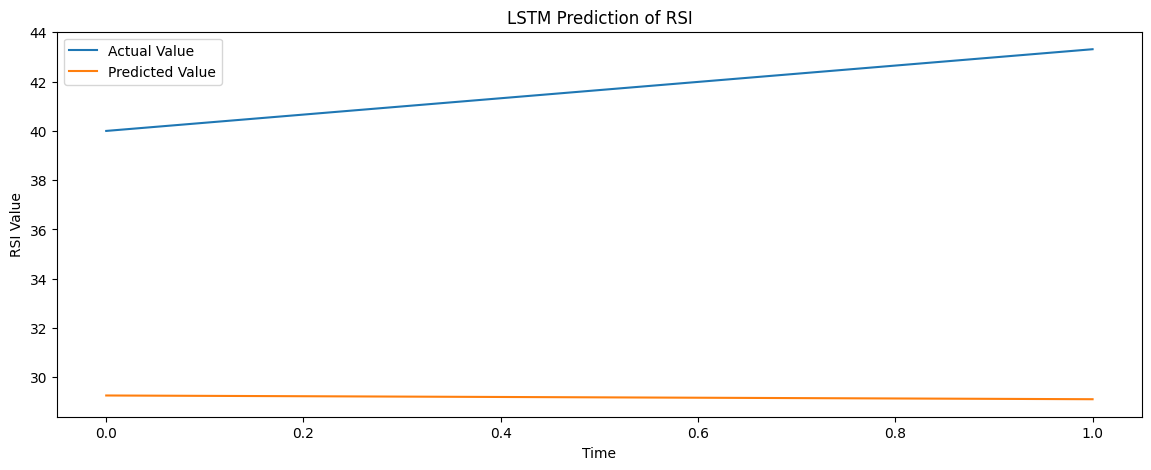

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
실시간 RSI 값: 43.31470893569661
다음 날 예측 RSI 값: 28.973583221435547


In [123]:
import talib as ta
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 최근 5개월 간의 AAPL 주식 데이터
ticker = 'AAPL'
data = yf.download(ticker, period='5mo', interval='1d')

# numpy 배열로 변환하여 ta-lib 함수 호출
close = data['Close'].to_numpy().astype(np.float64).flatten()
high = data['High'].to_numpy().astype(np.float64).flatten()
low = data['Low'].to_numpy().astype(np.float64).flatten()
volume = data['Volume'].to_numpy().astype(np.float64).flatten()

# 각 기술 지표 계산
data['RSI'] = ta.RSI(close, timeperiod=14)
data['MACD'], data['MACD_Signal'], data['MACD_Hist'] = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
data['SlowK'], data['SlowD'] = ta.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
data['CCI'] = ta.CCI(high, low, close, timeperiod=20)
data['MFI'] = ta.MFI(high, low, close, volume, timeperiod=14)
data['ADX'] = ta.ADX(high, low, close, timeperiod=14)
data['SMA'] = ta.SMA(close, timeperiod=20)
data['EMA'] = ta.EMA(close, timeperiod=20)
data['WMA'] = ta.WMA(close, timeperiod=20)
data['UpperBand'], data['MiddleBand'], data['LowerBand'] = ta.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
data['SAR'] = ta.SAR(high, low, acceleration=0.02, maximum=0.2)
data['ATR'] = ta.ATR(high, low, close, timeperiod=14)
data['NATR'] = ta.NATR(high, low, close, timeperiod=14)
data['TRANGE'] = ta.TRANGE(high, low, close)
data['OBV'] = ta.OBV(close, volume)
data['AD'] = ta.AD(high, low, close, volume)
data['ADOSC'] = ta.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

# NaN 값이 있는 행 제거
data = data.dropna()

# 예측할 지표 선택
indicator = input("예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등): ").strip()

if indicator not in data.columns:
    print(f"{indicator} 지표가 없습니다. 다시 실행해주세요.")
    exit()

# 데이터 전처리
values = data[[indicator]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# LSTM 입력 및 출력 생성
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_dataset(scaled_values, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 훈련 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# LSTM 모델 구성
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# 모델 훈련
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# 시각화
plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Actual Value')
plt.plot(predictions, label='Predicted Value')
plt.title(f'LSTM Prediction of {indicator}')
plt.xlabel('Time')
plt.ylabel(f'{indicator} Value')
plt.legend()
plt.show()

# 실시간 지표 값과 다음 날 예측 값 출력
latest_real_value = values[-1][0]
latest_input = scaled_values[-look_back:].reshape(1, look_back, 1)
next_day_prediction = model.predict(latest_input)
next_day_value = scaler.inverse_transform(next_day_prediction)[0][0]

print(f"실시간 {indicator} 값: {latest_real_value}")
print(f"다음 날 예측 {indicator} 값: {next_day_value}")


[*********************100%***********************]  1 of 1 completed


예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등):  RSI


Epoch 1/20


C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.0073 - val_loss: 0.0597
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 0.0076 - val_loss: 0.0502
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 0.0056 - val_loss: 0.0441
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - loss: 0.0058 - val_loss: 0.0404
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - loss: 0.0060 - val_loss: 0.0402
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 0.0031 - val_loss: 0.0411
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - loss: 0.0059 - val_loss: 0.0423
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - loss: 0.0055 - val_loss: 0.0441
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - loss: 0.0037 - val_loss: 0.0456
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - loss: 0.0038 - val_loss: 0.0468
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - loss: 0.0037 - val_loss: 0.0477
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - loss: 0.0033 - val_loss: 0.0479
Epo

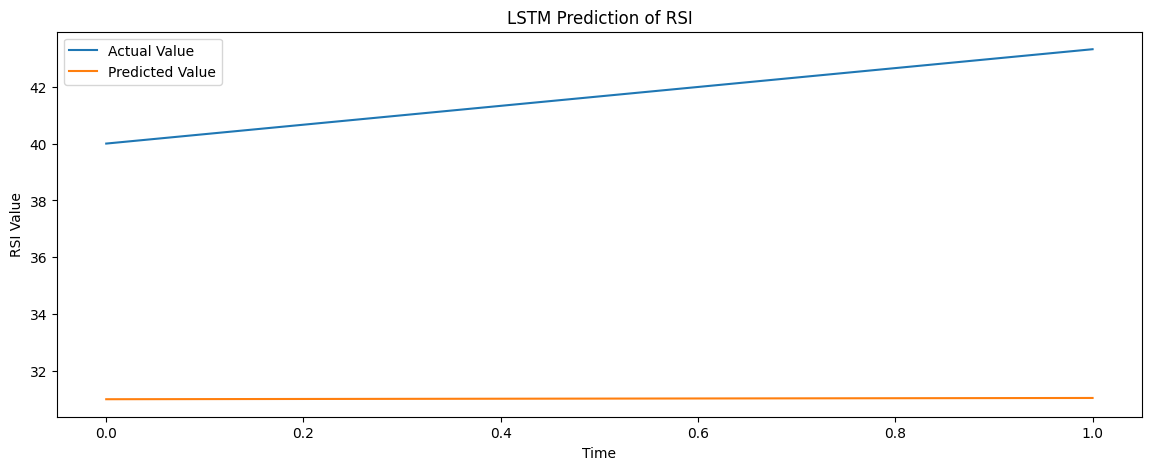

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step
실시간 RSI 값: 43.31470893569661
다음 날 예측 RSI 값: 31.116689682006836


In [124]:
import talib as ta
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 최근 5개월 간의 AAPL 주식 데이터
ticker = 'AAPL'
data = yf.download(ticker, period='5mo', interval='1d')

# numpy 배열로 변환하여 ta-lib 함수 호출
close = data['Close'].to_numpy().astype(np.float64).flatten()
high = data['High'].to_numpy().astype(np.float64).flatten()
low = data['Low'].to_numpy().astype(np.float64).flatten()
volume = data['Volume'].to_numpy().astype(np.float64).flatten()

# 각 기술 지표 계산
data['RSI'] = ta.RSI(close, timeperiod=14)
data['MACD'], data['MACD_Signal'], data['MACD_Hist'] = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
data['SlowK'], data['SlowD'] = ta.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
data['CCI'] = ta.CCI(high, low, close, timeperiod=20)
data['MFI'] = ta.MFI(high, low, close, volume, timeperiod=14)
data['ADX'] = ta.ADX(high, low, close, timeperiod=14)
data['SMA'] = ta.SMA(close, timeperiod=20)
data['EMA'] = ta.EMA(close, timeperiod=20)
data['WMA'] = ta.WMA(close, timeperiod=20)
data['UpperBand'], data['MiddleBand'], data['LowerBand'] = ta.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
data['SAR'] = ta.SAR(high, low, acceleration=0.02, maximum=0.2)
data['ATR'] = ta.ATR(high, low, close, timeperiod=14)
data['NATR'] = ta.NATR(high, low, close, timeperiod=14)
data['TRANGE'] = ta.TRANGE(high, low, close)
data['OBV'] = ta.OBV(close, volume)
data['AD'] = ta.AD(high, low, close, volume)
data['ADOSC'] = ta.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

# NaN 값이 있는 행 제거
data = data.dropna()

# 예측할 지표 선택
indicator = input("예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등): ").strip()

if indicator not in data.columns:
    print(f"{indicator} 지표가 없습니다. 다시 실행해주세요.")
    exit()

# 데이터 전처리
values = data[[indicator]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# LSTM 입력 및 출력 생성
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_dataset(scaled_values, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 훈련 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# LSTM 모델 구성
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# 모델 훈련
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# 시각화
plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Actual Value')
plt.plot(predictions, label='Predicted Value')
plt.title(f'LSTM Prediction of {indicator}')
plt.xlabel('Time')
plt.ylabel(f'{indicator} Value')
plt.legend()
plt.show()

# 실시간 지표 값과 다음 날 예측 값 출력
latest_real_value = values[-1][0]
latest_input = scaled_values[-look_back:].reshape(1, look_back, 1)
next_day_prediction = model.predict(latest_input)
next_day_value = scaler.inverse_transform(next_day_prediction)[0][0]

print(f"실시간 {indicator} 값: {latest_real_value}")
print(f"다음 날 예측 {indicator} 값: {next_day_value}")


[*********************100%***********************]  1 of 1 completed


예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등):  RSI


C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - loss: 0.0096 - val_loss: 0.0435
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - loss: 0.0042 - val_loss: 0.0319
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 0.0021 - val_loss: 0.0312
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - loss: 0.0102 - val_loss: 0.0406
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - loss: 0.0037 - val_loss: 0.0510
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - loss: 0.0053 - val_loss: 0.0586
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - loss: 0.0059 - val_loss: 0.0622
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 0.0060 - val_loss: 0.0622
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - loss: 0.0074 - val_loss: 0.0590
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 0.0037 - val_loss: 0.0539
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - loss: 0.0044 - val_loss: 0.0478
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - loss: 0.0050 - val_loss:

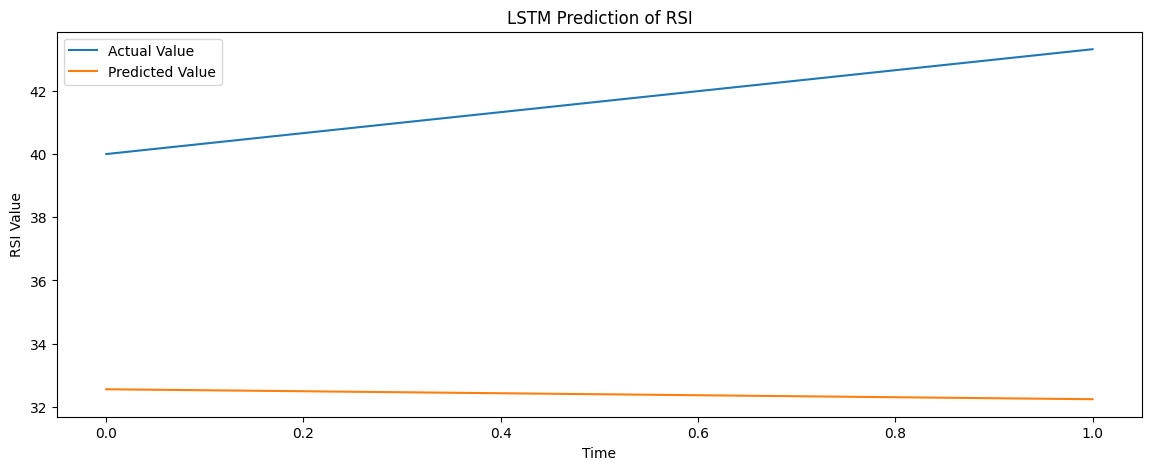

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
실시간 RSI 값: 43.31470893569661
다음 날 예측 RSI 값: 31.973644256591797


In [125]:
import talib as ta
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# 최근 5개월 간의 AAPL 주식 데이터
ticker = 'AAPL'
data = yf.download(ticker, period='5mo', interval='1d')

# numpy 배열로 변환하여 ta-lib 함수 호출
close = data['Close'].to_numpy().astype(np.float64).flatten()
high = data['High'].to_numpy().astype(np.float64).flatten()
low = data['Low'].to_numpy().astype(np.float64).flatten()
volume = data['Volume'].to_numpy().astype(np.float64).flatten()

# 각 기술 지표 계산
data['RSI'] = ta.RSI(close, timeperiod=14)
data['MACD'], data['MACD_Signal'], data['MACD_Hist'] = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
data['SlowK'], data['SlowD'] = ta.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
data['CCI'] = ta.CCI(high, low, close, timeperiod=20)
data['MFI'] = ta.MFI(high, low, close, volume, timeperiod=14)
data['ADX'] = ta.ADX(high, low, close, timeperiod=14)
data['SMA'] = ta.SMA(close, timeperiod=20)
data['EMA'] = ta.EMA(close, timeperiod=20)
data['WMA'] = ta.WMA(close, timeperiod=20)
data['UpperBand'], data['MiddleBand'], data['LowerBand'] = ta.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
data['SAR'] = ta.SAR(high, low, acceleration=0.02, maximum=0.2)
data['ATR'] = ta.ATR(high, low, close, timeperiod=14)
data['NATR'] = ta.NATR(high, low, close, timeperiod=14)
data['TRANGE'] = ta.TRANGE(high, low, close)
data['OBV'] = ta.OBV(close, volume)
data['AD'] = ta.AD(high, low, close, volume)
data['ADOSC'] = ta.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

# NaN 값이 있는 행 제거
data = data.dropna()

# 예측할 지표 선택
indicator = input("예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등): ").strip()

if indicator not in data.columns:
    print(f"{indicator} 지표가 없습니다. 다시 실행해주세요.")
    exit()

# 데이터 전처리
values = data[[indicator]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# LSTM 입력 및 출력 생성
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_dataset(scaled_values, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 훈련 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# LSTM 모델 구성
model = Sequential()
model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.3))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# 조기 종료 콜백 추가
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

# 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# 시각화
plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Actual Value')
plt.plot(predictions, label='Predicted Value')
plt.title(f'LSTM Prediction of {indicator}')
plt.xlabel('Time')
plt.ylabel(f'{indicator} Value')
plt.legend()
plt.show()

# 실시간 지표 값과 다음 날 예측 값 출력
latest_real_value = values[-1][0]
latest_input = scaled_values[-look_back:].reshape(1, look_back, 1)
next_day_prediction = model.predict(latest_input)
next_day_value = scaler.inverse_transform(next_day_prediction)[0][0]

print(f"실시간 {indicator} 값: {latest_real_value}")
print(f"다음 날 예측 {indicator} 값: {next_day_value}")


[*********************100%***********************]  1 of 1 completed


예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등):  RSI


C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - loss: 0.0164 - val_loss: 0.0226
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - loss: 0.0084 - val_loss: 0.0334
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - loss: 0.0054 - val_loss: 0.0509
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - loss: 0.0034 - val_loss: 0.0624
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - loss: 0.0050 - val_loss: 0.0630
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - loss: 0.0048 - val_loss: 0.0574
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - loss: 0.0066 - val_loss: 0.0485
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 0.0031 - val_loss: 0.0430
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - loss: 0.0032 - val_loss: 0.0405
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - loss: 0.0021 - val_loss: 0.0377
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - loss: 0.0045 - val_loss: 0.0407
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - loss: 0.00

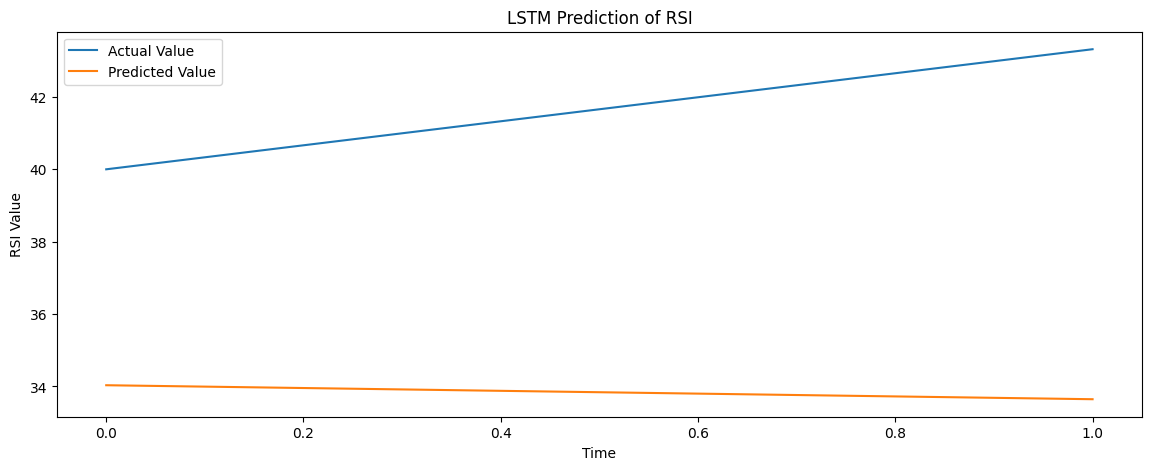

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
실시간 RSI 값: 43.31470893569661
다음 날 예측 RSI 값: 33.273773193359375


In [126]:
import talib as ta
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# 최근 5개월 간의 AAPL 주식 데이터
ticker = 'AAPL'
data = yf.download(ticker, period='5mo', interval='1d')

# numpy 배열로 변환하여 ta-lib 함수 호출
close = data['Close'].to_numpy().astype(np.float64).flatten()
high = data['High'].to_numpy().astype(np.float64).flatten()
low = data['Low'].to_numpy().astype(np.float64).flatten()
volume = data['Volume'].to_numpy().astype(np.float64).flatten()

# 각 기술 지표 계산
data['RSI'] = ta.RSI(close, timeperiod=14)
data['MACD'], data['MACD_Signal'], data['MACD_Hist'] = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
data['SlowK'], data['SlowD'] = ta.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
data['CCI'] = ta.CCI(high, low, close, timeperiod=20)
data['MFI'] = ta.MFI(high, low, close, volume, timeperiod=14)
data['ADX'] = ta.ADX(high, low, close, timeperiod=14)
data['SMA'] = ta.SMA(close, timeperiod=20)
data['EMA'] = ta.EMA(close, timeperiod=20)
data['WMA'] = ta.WMA(close, timeperiod=20)
data['UpperBand'], data['MiddleBand'], data['LowerBand'] = ta.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
data['SAR'] = ta.SAR(high, low, acceleration=0.02, maximum=0.2)
data['ATR'] = ta.ATR(high, low, close, timeperiod=14)
data['NATR'] = ta.NATR(high, low, close, timeperiod=14)
data['TRANGE'] = ta.TRANGE(high, low, close)
data['OBV'] = ta.OBV(close, volume)
data['AD'] = ta.AD(high, low, close, volume)
data['ADOSC'] = ta.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

# NaN 값이 있는 행 제거
data = data.dropna()

# 예측할 지표 선택
indicator = input("예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등): ").strip()

if indicator not in data.columns:
    print(f"{indicator} 지표가 없습니다. 다시 실행해주세요.")
    exit()

# 데이터 전처리
values = data[[indicator]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# LSTM 입력 및 출력 생성
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_dataset(scaled_values, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 훈련 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# LSTM 모델 구성
model = Sequential()
model.add(LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.4))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# 조기 종료 콜백 추가
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# 모델 훈련
model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), callbacks=[early_stopping])

# 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# 시각화
plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Actual Value')
plt.plot(predictions, label='Predicted Value')
plt.title(f'LSTM Prediction of {indicator}')
plt.xlabel('Time')
plt.ylabel(f'{indicator} Value')
plt.legend()
plt.show()

# 실시간 지표 값과 다음 날 예측 값 출력
latest_real_value = values[-1][0]
latest_input = scaled_values[-look_back:].reshape(1, look_back, 1)
next_day_prediction = model.predict(latest_input)
next_day_value = scaler.inverse_transform(next_day_prediction)[0][0]

print(f"실시간 {indicator} 값: {latest_real_value}")
print(f"다음 날 예측 {indicator} 값: {next_day_value}")


[*********************100%***********************]  1 of 1 completed


예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등):  Close


C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step - loss: 0.0100 - val_loss: 0.0093
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step - loss: 0.0563 - val_loss: 0.0237
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step - loss: 0.0032 - val_loss: 0.0495
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 578ms/step - loss: 0.0097 - val_loss: 0.0438
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step - loss: 0.0075 - val_loss: 0.0300
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step - loss: 0.0037 - val_loss: 0.0193
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step - loss: 0.0024 - val_loss: 0.0130
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step - loss: 0.0033 - val_loss: 0.0108
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step - loss: 0.0025 - val_loss: 0.0133
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step - loss: 0.0056 - val_loss: 0.0196
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step - loss: 0.0025 - val_loss: 0.0252
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step - loss: 0.00

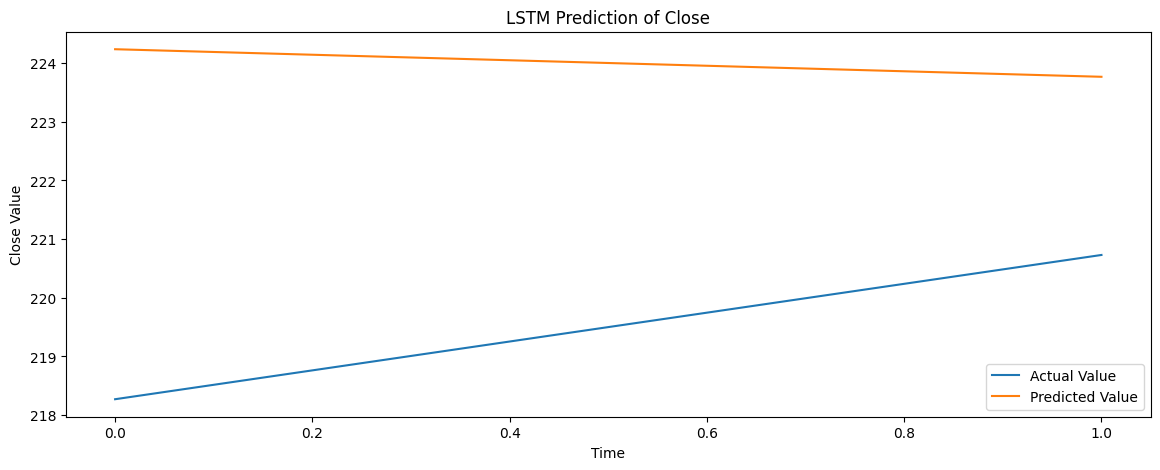

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
실시간 Close 값: 220.72999572753906
다음 날 예측 Close 값: 223.2561798095703


In [128]:
import talib as ta
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# 최근 5개월 간의 AAPL 주식 데이터
ticker = 'AAPL'
data = yf.download(ticker, period='5mo', interval='1d')

# numpy 배열로 변환하여 ta-lib 함수 호출
close = data['Close'].to_numpy().astype(np.float64).flatten()
high = data['High'].to_numpy().astype(np.float64).flatten()
low = data['Low'].to_numpy().astype(np.float64).flatten()
volume = data['Volume'].to_numpy().astype(np.float64).flatten()

# 각 기술 지표 계산
data['RSI'] = ta.RSI(close, timeperiod=14)
data['MACD'], data['MACD_Signal'], data['MACD_Hist'] = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
data['SlowK'], data['SlowD'] = ta.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
data['CCI'] = ta.CCI(high, low, close, timeperiod=20)
data['MFI'] = ta.MFI(high, low, close, volume, timeperiod=14)
data['ADX'] = ta.ADX(high, low, close, timeperiod=14)
data['SMA'] = ta.SMA(close, timeperiod=20)
data['EMA'] = ta.EMA(close, timeperiod=20)
data['WMA'] = ta.WMA(close, timeperiod=20)
data['UpperBand'], data['MiddleBand'], data['LowerBand'] = ta.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
data['SAR'] = ta.SAR(high, low, acceleration=0.02, maximum=0.2)
data['ATR'] = ta.ATR(high, low, close, timeperiod=14)
data['NATR'] = ta.NATR(high, low, close, timeperiod=14)
data['TRANGE'] = ta.TRANGE(high, low, close)
data['OBV'] = ta.OBV(close, volume)
data['AD'] = ta.AD(high, low, close, volume)
data['ADOSC'] = ta.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

# NaN 값이 있는 행 제거
data = data.dropna()

# 예측할 지표 선택
indicator = input("예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등): ").strip()

if indicator not in data.columns:
    print(f"{indicator} 지표가 없습니다. 다시 실행해주세요.")
    exit()

# 데이터 전처리
values = data[[indicator]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# LSTM 입력 및 출력 생성
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_dataset(scaled_values, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 훈련 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# LSTM 모델 구성
model = Sequential()
model.add(LSTM(512, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.4))
model.add(LSTM(256, return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.4))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# 조기 종료 콜백 추가
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

# 모델 훈련
model.fit(X_train, y_train, epochs=500, batch_size=16, validation_data=(X_test, y_test), callbacks=[early_stopping])

# 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# 시각화
plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Actual Value')
plt.plot(predictions, label='Predicted Value')
plt.title(f'LSTM Prediction of {indicator}')
plt.xlabel('Time')
plt.ylabel(f'{indicator} Value')
plt.legend()
plt.show()

# 실시간 지표 값과 다음 날 예측 값 출력
latest_real_value = values[-1][0]
latest_input = scaled_values[-look_back:].reshape(1, look_back, 1)
next_day_prediction = model.predict(latest_input)
next_day_value = scaler.inverse_transform(next_day_prediction)[0][0]

print(f"실시간 {indicator} 값: {latest_real_value}")
print(f"다음 날 예측 {indicator} 값: {next_day_value}")

[*********************100%***********************]  1 of 1 completed


예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등):  Close


Epoch 1/1000


C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - loss: 0.1901 - val_loss: 0.1208
Epoch 2/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 867ms/step - loss: 0.0760 - val_loss: 0.0715
Epoch 3/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 902ms/step - loss: 0.0421 - val_loss: 0.0741
Epoch 4/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 874ms/step - loss: 0.0286 - val_loss: 0.0803
Epoch 5/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 892ms/step - loss: 0.0205 - val_loss: 0.0407
Epoch 6/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 869ms/step - loss: 0.0143 - val_loss: 0.0345
Epoch 7/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 867ms/step - loss: 0.0106 - val_loss: 0.0372
Epoch 8/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 870ms/step - loss: 0.0144 - val_loss: 0.0278
Epoch 9/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 834ms/step - loss: 0.0107 - val_loss: 0.0229
Epoch 10/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 838ms/step - loss: 0.0120 - val_loss: 0.0281
Epoch 11/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 843ms/step - loss: 0.0125 - val_loss: 0.0163
Epoch 12/1000
11/11 ━━━━━━━━━━━━━━━━━━

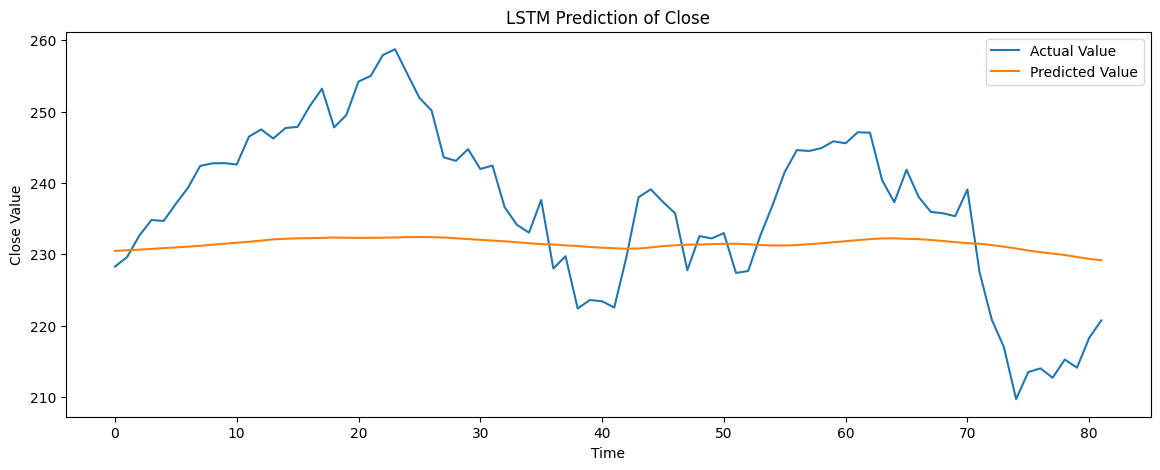

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
실시간 Close 값: 220.72999572753906
다음 날 예측 Close 값: 229.0388641357422


In [129]:
import talib as ta
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# ✅ 2년 간의 AAPL 주식 데이터 다운로드
ticker = 'AAPL'
data = yf.download(ticker, period='2y', interval='1d')

# ✅ numpy 배열로 변환
close = data['Close'].to_numpy().astype(np.float64).flatten()
high = data['High'].to_numpy().astype(np.float64).flatten()
low = data['Low'].to_numpy().astype(np.float64).flatten()
volume = data['Volume'].to_numpy().astype(np.float64).flatten()

# ✅ 기술 지표 계산
data['RSI'] = ta.RSI(close, timeperiod=14)
data['MACD'], data['MACD_Signal'], data['MACD_Hist'] = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
data['SlowK'], data['SlowD'] = ta.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
data['CCI'] = ta.CCI(high, low, close, timeperiod=20)
data['MFI'] = ta.MFI(high, low, close, volume, timeperiod=14)
data['ADX'] = ta.ADX(high, low, close, timeperiod=14)
data['SMA'] = ta.SMA(close, timeperiod=20)
data['EMA'] = ta.EMA(close, timeperiod=20)
data['WMA'] = ta.WMA(close, timeperiod=20)
data['UpperBand'], data['MiddleBand'], data['LowerBand'] = ta.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2)
data['SAR'] = ta.SAR(high, low, acceleration=0.02, maximum=0.2)
data['ATR'] = ta.ATR(high, low, close, timeperiod=14)
data['NATR'] = ta.NATR(high, low, close, timeperiod=14)
data['TRANGE'] = ta.TRANGE(high, low, close)
data['OBV'] = ta.OBV(close, volume)
data['AD'] = ta.AD(high, low, close, volume)
data['ADOSC'] = ta.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

# ✅ NaN 값 제거
data = data.dropna()

# ✅ 예측할 지표 선택
indicator = input("예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등): ").strip()
if indicator not in data.columns:
    print(f"{indicator} 지표가 없습니다. 다시 실행해주세요.")
    exit()

# ✅ 데이터 전처리
values = data[[indicator]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# ✅ LSTM 입력 및 출력 생성
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_dataset(scaled_values, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# ✅ 훈련 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ✅ LSTM 모델 구성 (정확도 강화)
model = Sequential()
model.add(Bidirectional(LSTM(512, return_sequences=True, input_shape=(X_train.shape[1], 1))))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(256, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(128, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# ✅ 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

# ✅ 조기 종료 콜백 추가
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

# ✅ 모델 훈련
model.fit(X_train, y_train, epochs=1000, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

# ✅ 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# ✅ 시각화
plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Actual Value')
plt.plot(predictions, label='Predicted Value')
plt.title(f'LSTM Prediction of {indicator}')
plt.xlabel('Time')
plt.ylabel(f'{indicator} Value')
plt.legend()
plt.show()

# ✅ 실시간 지표 값과 다음 날 예측 값 출력
latest_real_value = values[-1][0]
latest_input = scaled_values[-look_back:].reshape(1, look_back, 1)
next_day_prediction = model.predict(latest_input)
next_day_value = scaler.inverse_transform(next_day_prediction)[0][0]

print(f"실시간 {indicator} 값: {latest_real_value}")
print(f"다음 날 예측 {indicator} 값: {next_day_value}")


[*********************100%***********************]  1 of 1 completed


예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등):  Close


Epoch 1/1000


C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step - loss: 0.0998 - val_loss: 0.0419
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step - loss: 0.1569 - val_loss: 0.0414
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step - loss: 0.0498 - val_loss: 0.0387
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step - loss: 0.0488 - val_loss: 0.0320
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step - loss: 0.0232 - val_loss: 0.0248
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step - loss: 0.0086 - val_loss: 0.0212
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step - loss: 0.0064 - val_loss: 0.0201
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step - loss: 0.0155 - val_loss: 0.0213
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step - loss: 0.0084 - val_loss: 0.0220
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step - loss: 0.0168 - val_loss: 0.0227
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step - loss: 0.0184 - val_loss: 0.0249
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step - loss: 0.002

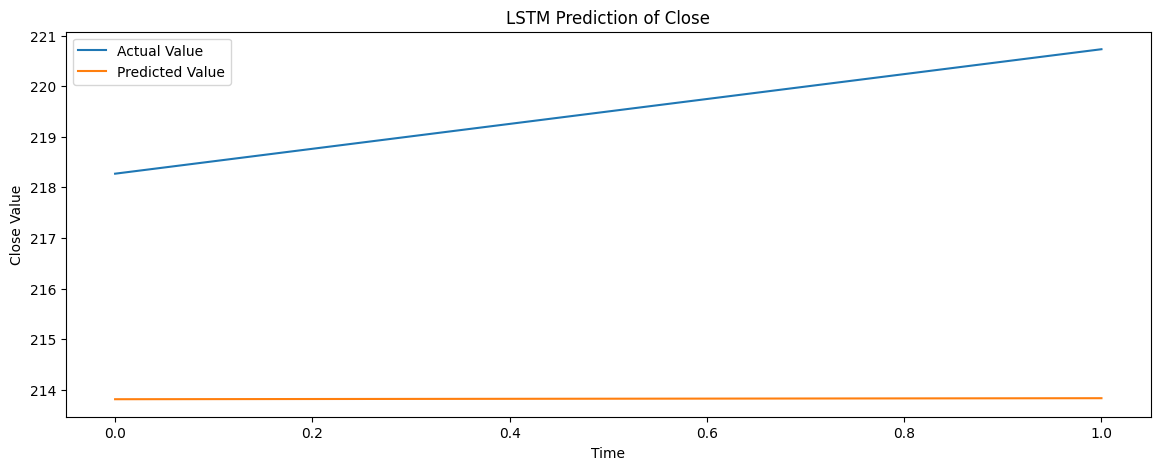

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
실시간 Close 값: 220.72999572753906
다음 날 예측 Close 값: 213.84902954101562


In [135]:
import talib as ta
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# ✅ 5개월 간의 AAPL 주식 데이터 다운로드
ticker = 'AAPL'
data = yf.download(ticker, period='5mo', interval='1d')

# ✅ numpy 배열로 변환
close = data['Close'].to_numpy().astype(np.float64).flatten()
high = data['High'].to_numpy().astype(np.float64).flatten()
low = data['Low'].to_numpy().astype(np.float64).flatten()
volume = data['Volume'].to_numpy().astype(np.float64).flatten()

# ✅ 기술 지표 계산
data['RSI'] = ta.RSI(close, timeperiod=14)
data['MACD'], data['MACD_Signal'], data['MACD_Hist'] = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
data['SlowK'], data['SlowD'] = ta.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
data['CCI'] = ta.CCI(high, low, close, timeperiod=20)
data['MFI'] = ta.MFI(high, low, close, volume, timeperiod=14)
data['ADX'] = ta.ADX(high, low, close, timeperiod=14)
data['SMA'] = ta.SMA(close, timeperiod=20)
data['EMA'] = ta.EMA(close, timeperiod=20)
data['WMA'] = ta.WMA(close, timeperiod=20)
data['UpperBand'], data['MiddleBand'], data['LowerBand'] = ta.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2)
data['SAR'] = ta.SAR(high, low, acceleration=0.02, maximum=0.2)
data['ATR'] = ta.ATR(high, low, close, timeperiod=14)
data['NATR'] = ta.NATR(high, low, close, timeperiod=14)
data['TRANGE'] = ta.TRANGE(high, low, close)
data['OBV'] = ta.OBV(close, volume)
data['AD'] = ta.AD(high, low, close, volume)
data['ADOSC'] = ta.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

# ✅ NaN 값 제거
data = data.dropna()

# ✅ 예측할 지표 선택
indicator = input("예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등): ").strip()
if indicator not in data.columns:
    print(f"{indicator} 지표가 없습니다. 다시 실행해주세요.")
    exit()

# ✅ 데이터 전처리
values = data[[indicator]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# ✅ LSTM 입력 및 출력 생성
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_dataset(scaled_values, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# ✅ 훈련 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ✅ LSTM 모델 구성 (정확도 강화)
model = Sequential()
model.add(Bidirectional(LSTM(512, return_sequences=True, input_shape=(X_train.shape[1], 1))))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(256, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(128, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# ✅ 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

# ✅ 조기 종료 콜백 추가
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

# ✅ 모델 훈련
model.fit(X_train, y_train, epochs=1000, batch_size=32, validation_data=(X_test, y_test))

# ✅ 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# ✅ 시각화
plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Actual Value')
plt.plot(predictions, label='Predicted Value')
plt.title(f'LSTM Prediction of {indicator}')
plt.xlabel('Time')
plt.ylabel(f'{indicator} Value')
plt.legend()
plt.show()

# ✅ 실시간 지표 값과 다음 날 예측 값 출력
latest_real_value = values[-1][0]
latest_input = scaled_values[-look_back:].reshape(1, look_back, 1)
next_day_prediction = model.predict(latest_input)
next_day_value = scaler.inverse_transform(next_day_prediction)[0][0]

print(f"실시간 {indicator} 값: {latest_real_value}")
print(f"다음 날 예측 {indicator} 값: {next_day_value}")


[*********************100%***********************]  1 of 1 completed


예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등):  Close


Epoch 1/500


C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step - loss: 0.1033 - val_loss: 0.0375
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 737ms/step - loss: 0.1359 - val_loss: 0.0441
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step - loss: 0.6566 - val_loss: 0.0405
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step - loss: 0.1639 - val_loss: 0.0419
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step - loss: 0.1347 - val_loss: 0.0453
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step - loss: 0.0856 - val_loss: 0.0487
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step - loss: 0.0816 - val_loss: 0.0553
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step - loss: 0.1163 - val_loss: 0.0587
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step - loss: 0.0556 - val_loss: 0.0562
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step - loss: 0.1099 - val_loss: 0.0544
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step - loss: 0.0462 - val_loss: 0.0498
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step - loss: 0.0751 - val_los

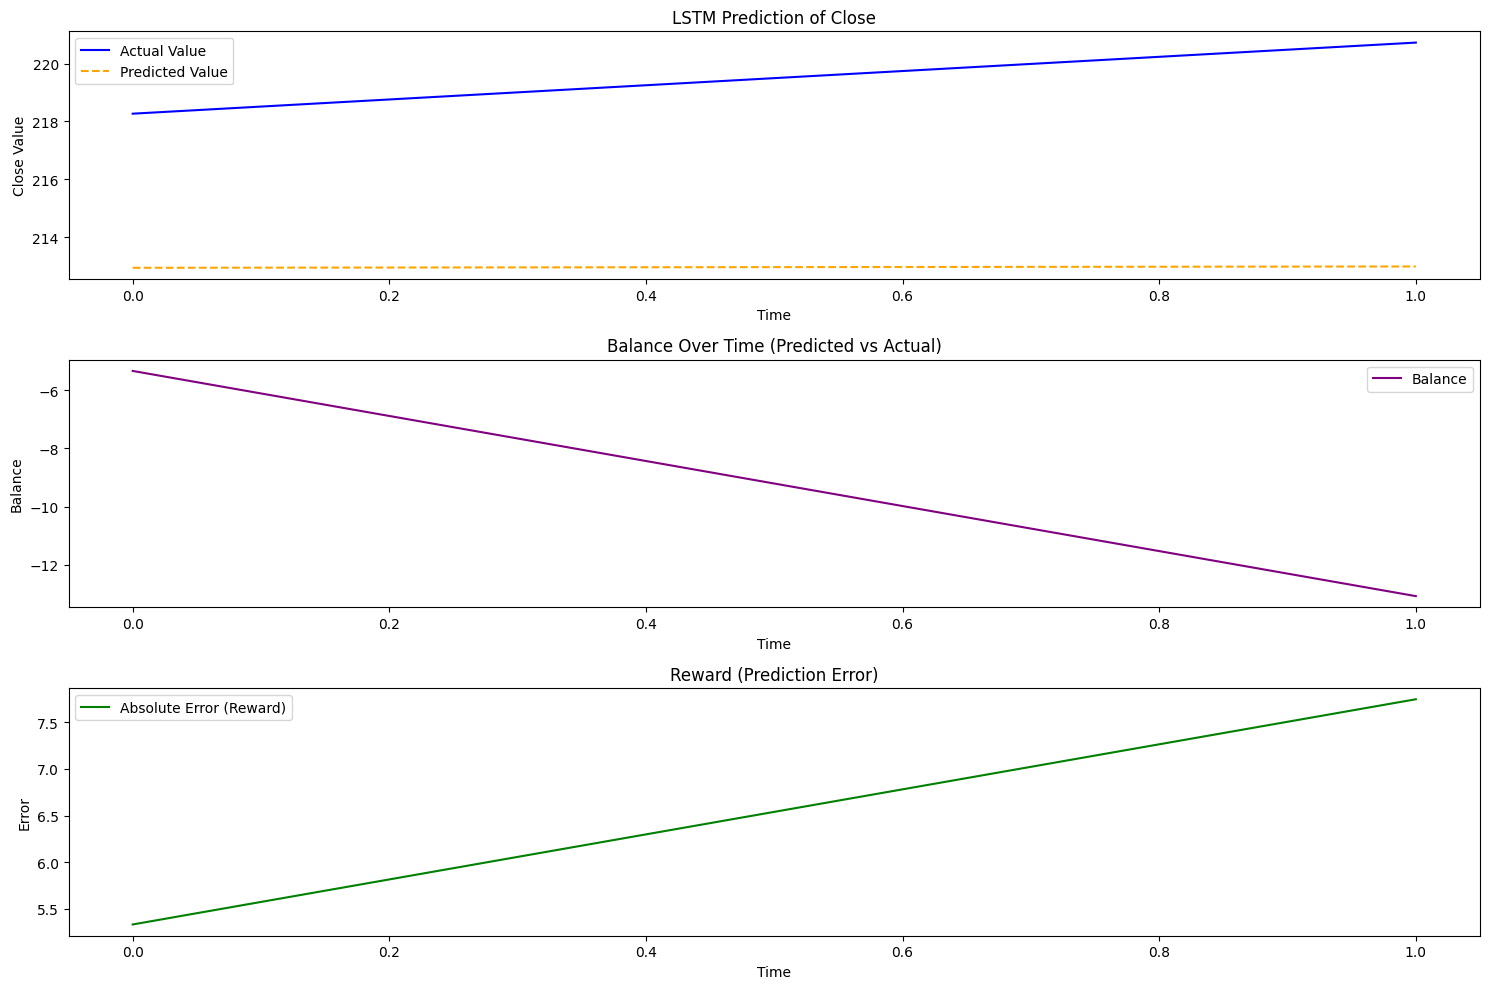

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

📊 실시간 Close 값: 220.72999572753906
📈 다음 날 예측 Close 값: 213.01358032226562


In [136]:
import talib as ta
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ✅ 5개월간의 AAPL 주식 데이터 다운로드
ticker = 'AAPL'
data = yf.download(ticker, period='5mo', interval='1d')

# ✅ numpy 배열로 변환
close = data['Close'].to_numpy().astype(np.float64).flatten()
high = data['High'].to_numpy().astype(np.float64).flatten()
low = data['Low'].to_numpy().astype(np.float64).flatten()
volume = data['Volume'].to_numpy().astype(np.float64).flatten()

# ✅ 기술 지표 계산
data['RSI'] = ta.RSI(close, timeperiod=14)
data['MACD'], data['MACD_Signal'], data['MACD_Hist'] = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
data['SlowK'], data['SlowD'] = ta.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
data['CCI'] = ta.CCI(high, low, close, timeperiod=20)
data['MFI'] = ta.MFI(high, low, close, volume, timeperiod=14)
data['ADX'] = ta.ADX(high, low, close, timeperiod=14)
data['SMA'] = ta.SMA(close, timeperiod=20)
data['EMA'] = ta.EMA(close, timeperiod=20)
data['WMA'] = ta.WMA(close, timeperiod=20)
data['UpperBand'], _, data['LowerBand'] = ta.BBANDS(close, timeperiod=20)
data['SAR'] = ta.SAR(high, low, acceleration=0.02, maximum=0.2)
data['ATR'] = ta.ATR(high, low, close, timeperiod=14)
data['OBV'] = ta.OBV(close, volume)

# ✅ NaN 값 제거
data = data.dropna()

# ✅ 예측할 지표 선택
indicator = input("예측할 지표를 입력하세요 (예: RSI, MACD, SlowK 등): ").strip()
if indicator not in data.columns:
    print(f"{indicator} 지표가 없습니다. 다시 실행해주세요.")
    exit()

# ✅ 데이터 전처리
values = data[[indicator]].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# ✅ LSTM 입력 및 출력 생성
def create_dataset(dataset, look_back=60):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_dataset(scaled_values, look_back)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# ✅ 훈련 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ✅ LSTM 모델 구성 (정확도 강화)
model = Sequential()
model.add(Bidirectional(LSTM(512, return_sequences=True, input_shape=(X_train.shape[1], 1))))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(LSTM(256, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(LSTM(128, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# ✅ 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

# ✅ 모델 훈련 (중단 없이 끝까지 훈련)
model.fit(X_train, y_train, epochs=500, batch_size=32, validation_data=(X_test, y_test))

# ✅ 예측
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# ✅ 시각화
plt.figure(figsize=(15, 10))

# 1. 실제 값과 예측 값
plt.subplot(3, 1, 1)
plt.plot(y_test, label='Actual Value', color='blue')
plt.plot(predictions, label='Predicted Value', color='orange', linestyle='--')
plt.title(f'LSTM Prediction of {indicator}')
plt.xlabel('Time')
plt.ylabel(f'{indicator} Value')
plt.legend()

# 2. 잔고 변화 (예시)
plt.subplot(3, 1, 2)
balances = np.cumsum(predictions - y_test)  # 차이를 누적 합산하여 잔고로 사용
plt.plot(balances, label='Balance', color='purple')
plt.title('Balance Over Time (Predicted vs Actual)')
plt.xlabel('Time')
plt.ylabel('Balance')
plt.legend()

# 3. 보상 (절대 차이)
plt.subplot(3, 1, 3)
rewards = np.abs(predictions - y_test)
plt.plot(rewards, label='Absolute Error (Reward)', color='green')
plt.title('Reward (Prediction Error)')
plt.xlabel('Time')
plt.ylabel('Error')
plt.legend()

plt.tight_layout()
plt.show()

# ✅ 실시간 지표 값과 다음 날 예측 값 출력
latest_real_value = values[-1][0]
latest_input = scaled_values[-look_back:].reshape(1, look_back, 1)
next_day_prediction = model.predict(latest_input)
next_day_value = scaler.inverse_transform(next_day_prediction)[0][0]

print(f"\n📊 실시간 {indicator} 값: {latest_real_value}")
print(f"📈 다음 날 예측 {indicator} 값: {next_day_value}")
